# Lorentzian Pulse: Time and Frequency Domains

Set `FIGURE_TARGET` to `"paper"`, `"presentation_ips"`, or `"both"` to choose the output style. Set `PULSE_TARGET` to `"standard"`, `"echo"`, `"overlay"`, or `"both"` to save standard-only, echo-only, and overlay plots.


In [1]:
from __future__ import annotations

import os

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/ars-matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from echospec.figures import FigureVariant, apply_figure_style, save_figure
from echospec.simulation.pulses import PulseArgs, lorentzian_envelope
from echospec.utils.parameters import Parameters

# Choose one of: "paper", "presentation_ips", or "both".
FIGURE_TARGET = "both"

# Choose one of: "standard", "echo", "overlay", or "both".
# "both" saves standard-only, echo-only, and overlay figures.
PULSE_TARGET = "both"

OUTPUT_STEM = "lorentzian_time_and_frequency"
SAVE_FORMATS = ("png",)

PAPER_PULSE_LENGTH = 40e-6
PAPER_CUTOFF = 1e-3
PRESENTATION_PULSE_LENGTH = 20e-6
# Higher cutoff gives a larger effective Lorentzian tau inside the shorter window.
PRESENTATION_CUTOFF = 7.5e-2

# A power-of-two grid keeps the FFT fast while retaining smooth spectra.
N_SAMPLES = 2**20
SPAN_FACTOR = 20

COLOR_STANDARD = "#7b0134"
COLOR_ECHO = "#00a7c8"
COLOR_T2 = "#2f7d32"
COLOR_CUTOFF = "#c93b2b"


def selected_variants(target: str | FigureVariant) -> list[FigureVariant]:
    if isinstance(target, FigureVariant):
        return [target]
    if target == "both":
        return [FigureVariant.PAPER, FigureVariant.PRESENTATION_IPS]
    return [FigureVariant(target)]


def selected_pulse_modes(target: str) -> list[str]:
    allowed = {"standard", "echo", "overlay", "both"}
    if target not in allowed:
        raise ValueError(f"PULSE_TARGET must be one of {sorted(allowed)}, got {target!r}.")
    if target == "both":
        return ["standard", "echo", "overlay"]
    return [target]


def pulse_mode_stem(base_stem: str, pulse_mode: str) -> str:
    return f"{base_stem}_{pulse_mode}"


def pulse_parameters_for(variant: FigureVariant) -> tuple[float, float]:
    if variant is FigureVariant.PRESENTATION_IPS:
        return PRESENTATION_PULSE_LENGTH, PRESENTATION_CUTOFF
    return PAPER_PULSE_LENGTH, PAPER_CUTOFF


Matplotlib is building the font cache; this may take a moment.


In [2]:
def make_lorentzian_pulse_data(
    *,
    pulse_length: float,
    cutoff: float,
) -> dict[str, np.ndarray | float | Parameters]:
    params = Parameters()
    params.cutoff = cutoff
    params.pulse_length = pulse_length
    params.rabi_frequency = 50 * 2 * np.pi * 1e6

    t = np.linspace(
        -SPAN_FACTOR * pulse_length,
        SPAN_FACTOR * pulse_length,
        N_SAMPLES,
        endpoint=False,
    )

    x_start = -pulse_length / 2
    x_end = pulse_length / 2
    window = ((t >= x_start) & (t <= x_end)).astype(float)

    pulse_args = PulseArgs(pulse_length=pulse_length, cutoff=params.cutoff)
    omega = lorentzian_envelope(t, pulse_args) * params.rabi_frequency * window
    omega_echo = omega.copy()
    omega_echo[t >= 0] *= -1

    dt = t[1] - t[0]
    freq = np.fft.fftshift(np.fft.fftfreq(t.size, d=dt))
    fft_standard = np.fft.fftshift(np.fft.fft(omega))
    fft_echo = np.fft.fftshift(np.fft.fft(omega_echo))

    fft_standard = np.abs(fft_standard) / np.max(np.abs(fft_standard))
    fft_echo = np.abs(fft_echo) / np.max(np.abs(fft_echo))

    return {
        "params": params,
        "pulse_length_us": pulse_length / 1e-6,
        "cutoff": cutoff,
        "t": t,
        "t_us": t / 1e-6,
        "omega_mhz": omega / (2 * np.pi * 1e6),
        "omega_echo_mhz": omega_echo / (2 * np.pi * 1e6),
        "freq_khz": freq / 1e3,
        "fft_standard": fft_standard,
        "fft_echo": fft_echo,
        "x_start_us": x_start / 1e-6,
        "x_end_us": x_end / 1e-6,
        "t2_khz": params.T2_limit / 2 / 1e3,
    }


In [3]:
def plot_lorentzian_time_and_frequency(
    data: dict[str, np.ndarray | float | Parameters],
    *,
    variant: FigureVariant,
    pulse_mode: str,
) -> plt.Figure:
    plt.rcParams.update(plt.rcParamsDefault)
    apply_figure_style(variant)

    t_us = data["t_us"]
    omega = data["omega_mhz"]
    omega_echo = data["omega_echo_mhz"]
    freq_khz = data["freq_khz"]
    fft_standard = data["fft_standard"]
    fft_echo = data["fft_echo"]
    x_start_us = float(data["x_start_us"])
    x_end_us = float(data["x_end_us"])
    t2_khz = float(data["t2_khz"])

    show_standard = pulse_mode in {"standard", "overlay"}
    show_echo = pulse_mode in {"echo", "overlay"}
    if not (show_standard or show_echo):
        raise ValueError(f"Unsupported pulse mode: {pulse_mode!r}")

    all_time_traces = [omega, omega_echo]
    shown_time_traces = []
    if show_standard:
        shown_time_traces.append(omega)
    if show_echo:
        shown_time_traces.append(omega_echo)
    time_ylim = (
        -1.1 * max(np.max(np.abs(trace)) for trace in all_time_traces),
        1.1 * max(np.max(np.abs(trace)) for trace in all_time_traces),
    )

    if variant is FigureVariant.PRESENTATION_IPS:
        fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(5.2, 7.2), constrained_layout=True)
        line_width = 2.4
        cutoff_width = 1.6
        time_xlim = (-12, 12)
        freq_xlim = (-250, 250)
        show_insets = False
        show_panel_labels = False
        legend_loc = "upper right"
    else:
        fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(3.8, 4.0), constrained_layout=True)
        line_width = 0.8
        cutoff_width = 0.8
        time_xlim = (-40, 40)
        freq_xlim = (-1000, 1000)
        show_insets = True
        show_panel_labels = True
        legend_loc = "lower left"

    if show_standard:
        ax_time.plot(t_us, omega, color=COLOR_STANDARD, linewidth=line_width, label="Standard")
    if show_echo:
        ax_time.plot(
            t_us,
            omega_echo,
            color=COLOR_ECHO,
            linestyle="--",
            linewidth=line_width,
            label="Echo",
        )
    ax_time.axhline(0, color="0.25", linewidth=cutoff_width * 0.8)
    ax_time.axvline(x_start_us, color=COLOR_CUTOFF, linestyle=":", linewidth=cutoff_width, label="Cutoff")
    ax_time.axvline(x_end_us, color=COLOR_CUTOFF, linestyle=":", linewidth=cutoff_width)
    ax_time.set(
        xlabel=r"Time ($\mu$s)",
        ylabel=r"$\Omega(t)/2\pi$ (MHz)",
        xlim=time_xlim,
        ylim=time_ylim,
    )
    if variant is FigureVariant.PRESENTATION_IPS:
        title_suffix = {
            "standard": "standard pulse",
            "echo": "echo pulse",
            "overlay": "standard and echo pulses",
        }[pulse_mode]
        ax_time.set_title(f"Time domain: {title_suffix}")
        if show_standard:
            ax_time.fill_between(t_us, 0, omega, color=COLOR_STANDARD, alpha=0.18)
        if show_echo:
            ax_time.fill_between(t_us, 0, omega_echo, color=COLOR_ECHO, alpha=0.18)
    ax_time.legend(loc=legend_loc)

    if show_standard:
        ax_fft.plot(freq_khz, fft_standard, color=COLOR_STANDARD, linewidth=line_width, label="Standard")
    if show_echo:
        ax_fft.plot(freq_khz, fft_echo, color=COLOR_ECHO, linewidth=line_width, label="Echo")
    ax_fft.axvline(t2_khz, color=COLOR_T2, linestyle=":", linewidth=cutoff_width, label=r"$T_2$ limit")
    ax_fft.axvline(-t2_khz, color=COLOR_T2, linestyle=":", linewidth=cutoff_width)
    ax_fft.set(
        xlabel="Baseband frequency (kHz)",
        ylabel=r"Normalized $|\Omega(f)|$",
        xlim=freq_xlim,
        yscale="log",
        ylim=(1e-2, 1.5),
    )
    if variant is FigureVariant.PRESENTATION_IPS:
        ax_fft.set_title("Frequency domain")
    ax_fft.legend(loc="lower right")

    if show_insets:
        pulse_mask = (t_us >= x_start_us) & (t_us <= x_end_us)
        inset_min = min(trace[pulse_mask].min() for trace in shown_time_traces)
        inset_max = max(trace[pulse_mask].max() for trace in shown_time_traces)

        ax_time_inset = ax_time.inset_axes([0.64, 0.62, 0.3, 0.3])
        if show_standard:
            ax_time_inset.plot(t_us[pulse_mask], omega[pulse_mask], color=COLOR_STANDARD, linewidth=line_width)
        if show_echo:
            ax_time_inset.plot(
                t_us[pulse_mask],
                omega_echo[pulse_mask],
                color=COLOR_ECHO,
                linestyle="--",
                linewidth=line_width,
            )
        ax_time_inset.set_xlim(-0.1, 0.1)
        ax_time_inset.set_ylim(1.07 * inset_min, 1.07 * inset_max)
        ax_time_inset.set_yticks([])

        ax_cutoff_inset = ax_time.inset_axes([0.1, 0.7, 0.13, 0.2])
        if show_standard:
            ax_cutoff_inset.plot(t_us, omega, color=COLOR_STANDARD, linewidth=line_width)
        if show_echo:
            ax_cutoff_inset.plot(t_us, omega_echo, color=COLOR_ECHO, linestyle="--", linewidth=line_width)
        ax_cutoff_inset.axvline(x_start_us, color=COLOR_CUTOFF, linestyle=":", linewidth=cutoff_width)
        ax_cutoff_inset.set_xlim(x_start_us - 2, x_start_us + 2)
        ax_cutoff_inset.set_ylim(-0.005, 0.1)
        ax_cutoff_inset.set_xticks([x_start_us - 2, x_start_us + 2])
        ax_cutoff_inset.set_yticks([])

        zoom_halfwidth = 40.0
        zoom_mask = (freq_khz >= -zoom_halfwidth) & (freq_khz <= zoom_halfwidth)
        ax_fft_inset = ax_fft.inset_axes([0.05, 0.15, 0.3, 0.3])
        if show_standard:
            ax_fft_inset.plot(freq_khz, fft_standard, color=COLOR_STANDARD, linewidth=line_width)
        if show_echo:
            ax_fft_inset.plot(freq_khz, fft_echo, color=COLOR_ECHO, linewidth=line_width)
        ax_fft_inset.axvline(t2_khz, color=COLOR_T2, linestyle="--", linewidth=cutoff_width)
        ax_fft_inset.axvline(-t2_khz, color=COLOR_T2, linestyle="--", linewidth=cutoff_width)
        zoom_max = 0.0
        if show_standard:
            zoom_max = max(zoom_max, fft_standard[zoom_mask].max())
        if show_echo:
            zoom_max = max(zoom_max, fft_echo[zoom_mask].max())
        ax_fft_inset.set(
            xlim=(-zoom_halfwidth, zoom_halfwidth),
            yscale="log",
            ylim=(2e-2, 1.2 * zoom_max),
        )
        ax_fft_inset.set_yticks([])

        mark_inset(ax_time, ax_time_inset, loc1=2, loc2=4, fc="none", ec="lightgray")
        mark_inset(ax_time, ax_cutoff_inset, loc1=3, loc2=1, fc="none", ec="lightgray")
        mark_inset(ax_fft, ax_fft_inset, loc1=2, loc2=4, fc="none", ec="lightgray")

    if show_panel_labels:
        for label, ax in zip(["(a)", "(b)"], [ax_time, ax_fft]):
            ax.annotate(
                label,
                xy=(-0.08, 1.03),
                xycoords="axes fraction",
                ha="left",
                va="bottom",
                fontsize="large",
            )

    return fig


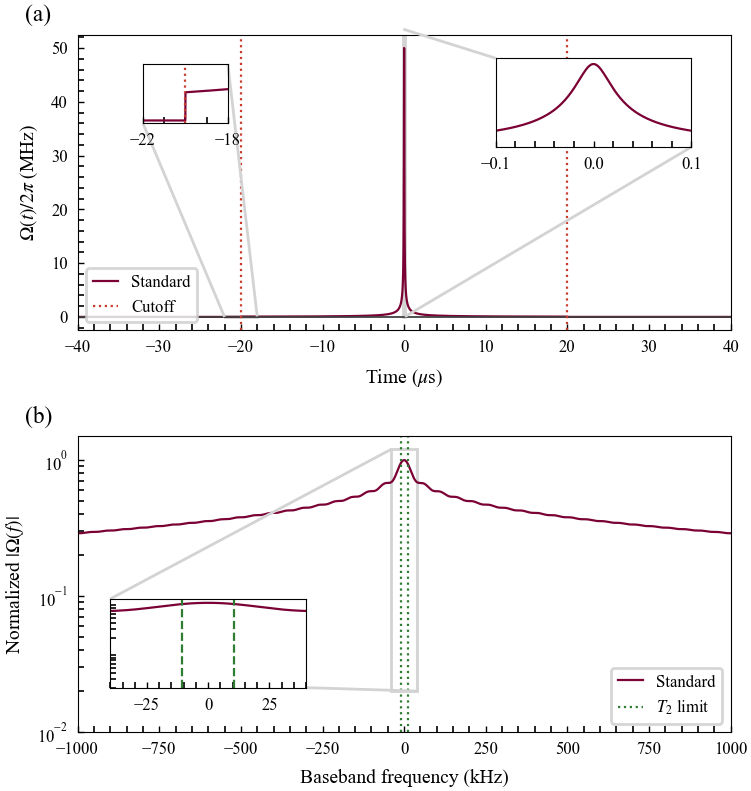

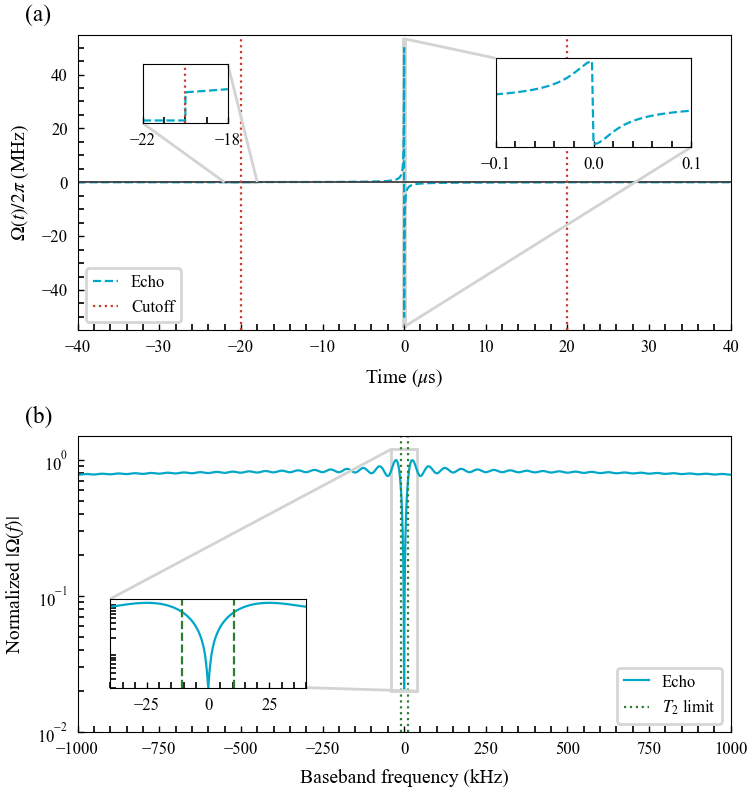

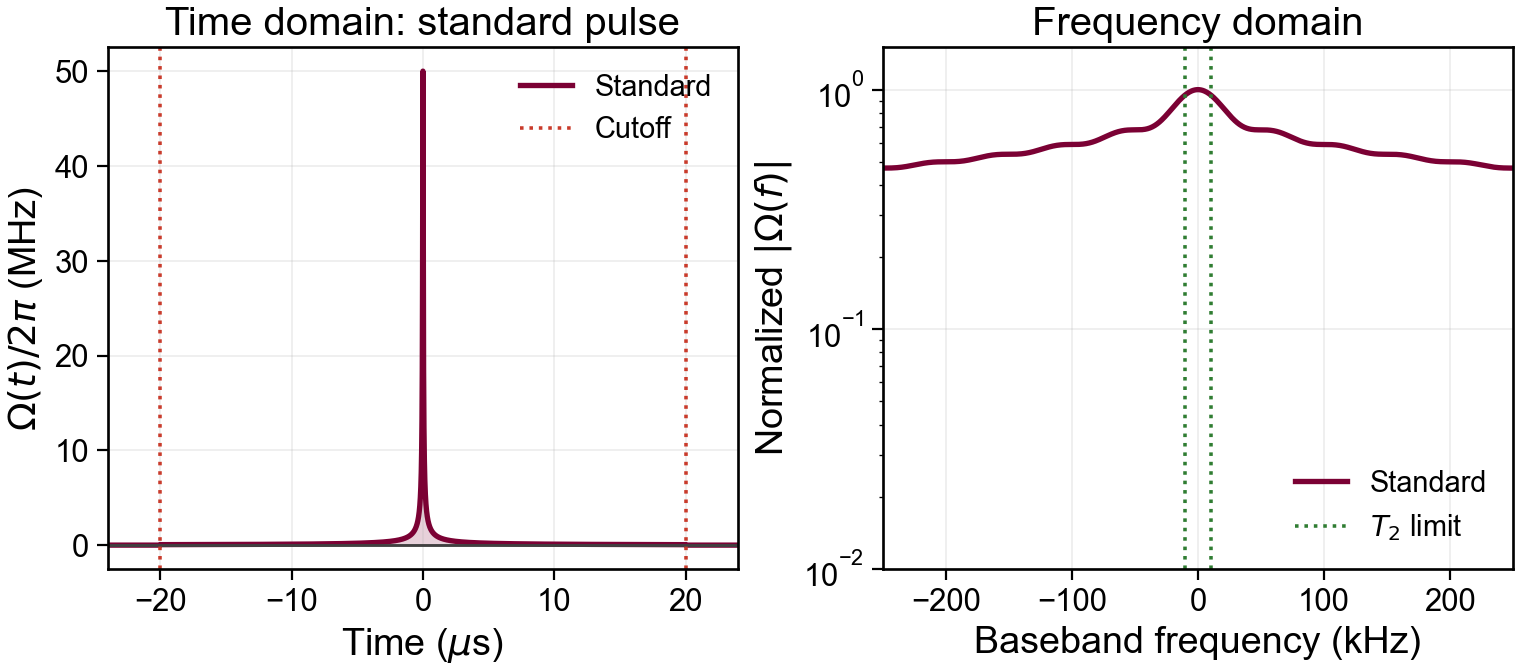

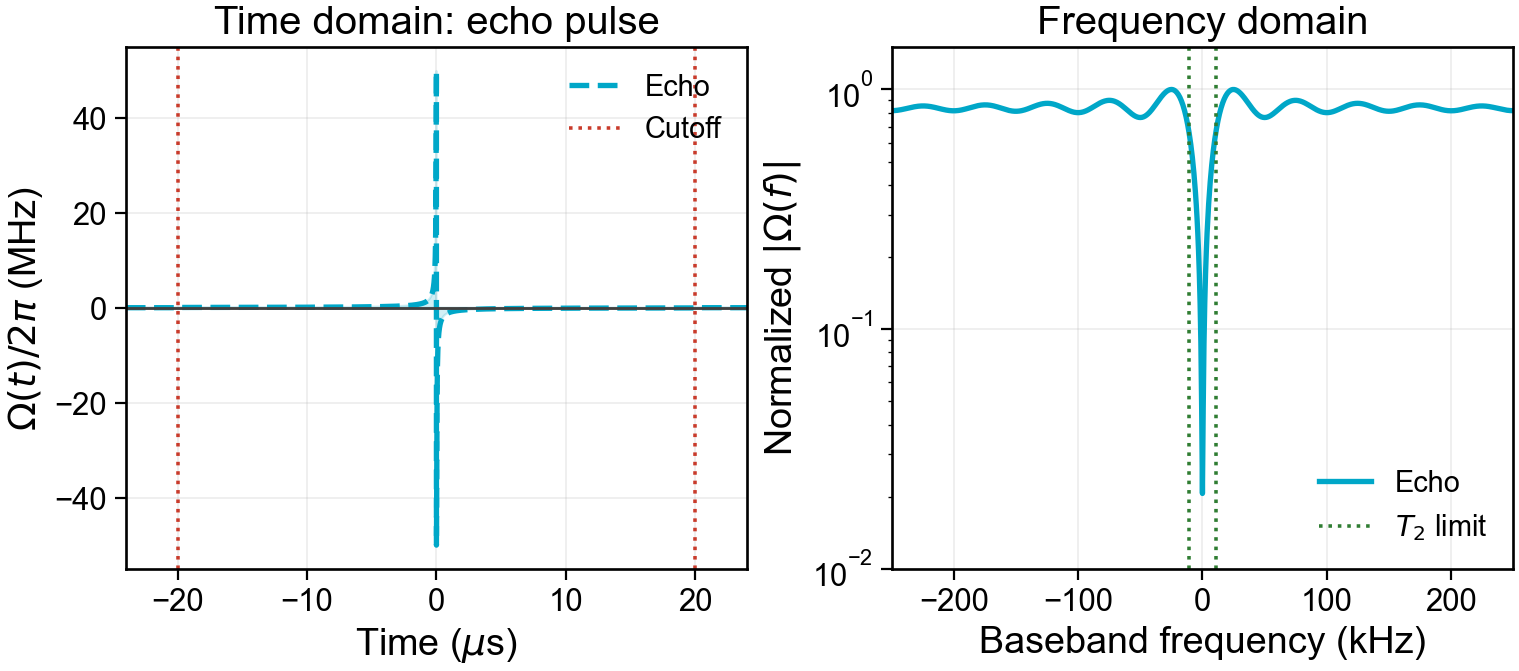

[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/lorentzian_time_and_frequency_standard.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/lorentzian_time_and_frequency_echo.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/presentation_ips/lorentzian_time_and_frequency_standard.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/presentation_ips/lorentzian_time_and_frequency_echo.png')]

In [4]:
saved_paths = []
for variant in selected_variants(FIGURE_TARGET):
    pulse_length, cutoff = pulse_parameters_for(variant)
    data = make_lorentzian_pulse_data(pulse_length=pulse_length, cutoff=cutoff)

    for pulse_mode in selected_pulse_modes(PULSE_TARGET):
        fig = plot_lorentzian_time_and_frequency(
            data,
            variant=variant,
            pulse_mode=pulse_mode,
        )
        saved_paths.extend(
            save_figure(
                fig,
                pulse_mode_stem(OUTPUT_STEM, pulse_mode),
                variant=variant,
                formats=SAVE_FORMATS,
            )
        )
        plt.show()

saved_paths
